In [1]:
import numpy as np
import scarf

scarf.configure_output(level='WARNING', progress=True)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    'tenx_5K_pbmc_rnaseq',
    destination='scarf_datasets',
    zarr=True,
)
ds = scarf.DataStore(
    f'{dataset}/data.zarr',
    nthreads=4,
)

Downloading bucket files: 38209567 / 38209567 complete

Downloading bytes: 38209567 / 38209567 complete

In [2]:
markers = ds.get_markers(
    group_key='RNA_clusters',
    group_id='1',
    min_score=-1,
    min_frac_exp=-1,
)
markers[
    [
        'feature_name',
        'score',
        'frac_exp',
        'fold_change',
        'auc',
        'p_value',
        'p_value_adjusted',
    ]
].head(10)

,feature_name,score,frac_exp,fold_change,auc,p_value,p_value_adjusted
0,ADTRP,0.65392,0.23870,15.33521,0.60948,2.476793e-109,1.832955e-107
1,TSHZ2,0.57190,0.32593,6.75262,0.63942,4.094205e-123,3.677832e-121
2,ANKRD55,0.56296,0.14750,19.15811,0.56922,4.492931e-72,1.649679e-70
3,CHRM3-AS2,0.50922,0.38303,8.24963,0.66602,6.665595e-152,8.278669e-150
4,TCEA3,0.50281,0.21015,7.79982,0.59004,7.034657e-76,2.737766e-74
5,AC005842.1,0.49610,0.15860,8.94126,0.56970,6.153527e-62,1.764876e-60
6,FHIT,0.48549,0.61856,10.59005,0.77698,9.127469e-289,4.345588e-286
7,CMTM8,0.48413,0.30531,5.11208,0.62095,8.656853e-89,4.719307e-87
8,EPHX2,0.44864,0.39017,7.32016,0.66482,2.346257e-142,2.577815e-140
9,MAN1C1,0.43633,0.31483,5.10983,0.62223,3.442119e-85,1.689477e-83


Aggregating marker values per group: 2 / 2 complete

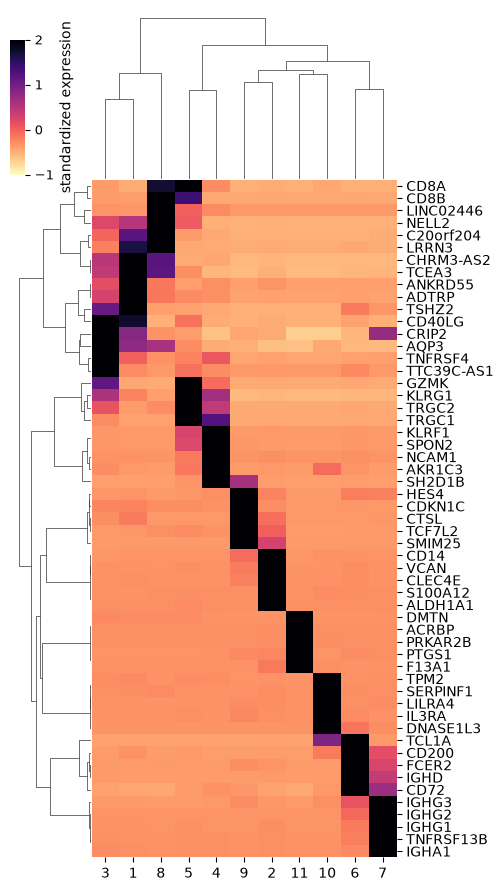

In [3]:
ds.plots.marker_heatmap(
    group_key='RNA_clusters',
    topn=5,
    figsize=(5, 9),
)

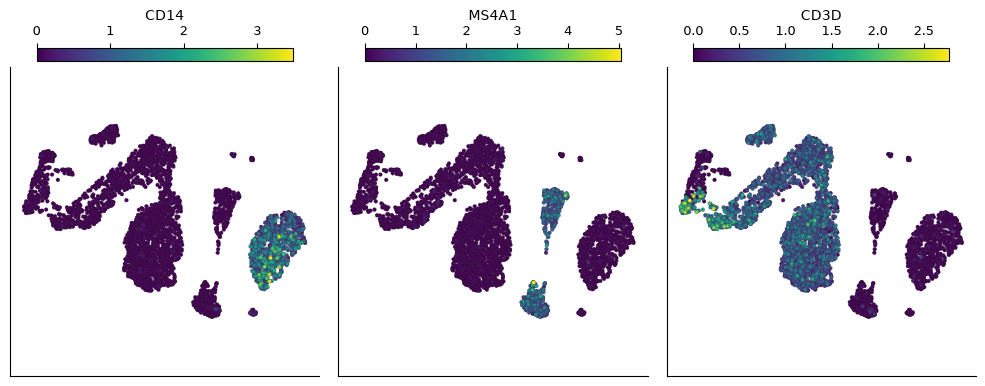

In [4]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by=['CD14', 'MS4A1', 'CD3D'],
    n_columns=3,
    sort_values=True,
)

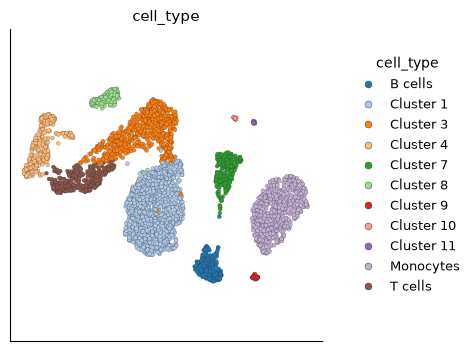

In [5]:
cluster_ids = ds.cells.fetch_all('RNA_clusters')
unique = sorted(
    {str(c) for c in cluster_ids},
    key=lambda x: (0, int(x)) if x.isdigit() else (1, x),
)

markers = ds.get_markers(
    group_key='RNA_clusters',
    group_id=None,
    min_score=-1,
    min_frac_exp=-1,
)

label_map = {c: f'Cluster {c}' for c in unique}
for gene, name in [('CD14', 'Monocytes'), ('MS4A1', 'B cells'), ('CD3D', 'T cells')]:
    hit = markers[markers['feature_name'].astype(str) == gene]
    if hit.empty:
        continue
    cid = str(hit.sort_values('score', ascending=False).iloc[0]['group_id'])
    label_map[cid] = name

labels = np.array([label_map[str(c)] for c in cluster_ids], dtype=object)
ds.cells.insert(column_name='cell_type', values=labels, overwrite=True)
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='cell_type',
)

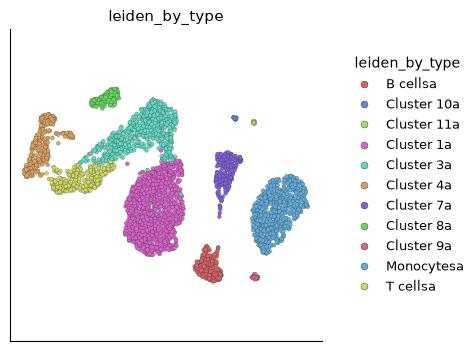

In [6]:
ds.smart_label(
    to_relabel='RNA_clusters',
    base_label='cell_type',
    new_col_name='leiden_by_type',
)
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='leiden_by_type',
)